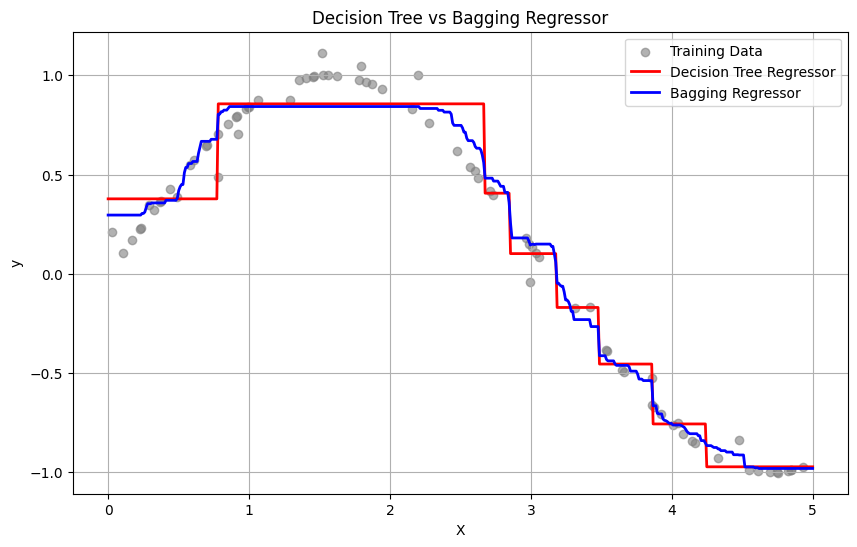

📊 Performance on Training Data:
  ➤ Decision Tree Regressor R²: 0.967, MSE: 0.016
  ➤ Bagging Regressor R²: 0.983, MSE: 0.009


'Output -\n📊 Performance on Training Data:\n  ➤ Decision Tree Regressor R²: 0.967, MSE: 0.016\n  ➤ Bagging Regressor R²: 0.983, MSE: 0.009\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
# 1. Generate synthetic regression data
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 0.5 * (np.random.rand(16) - 0.5)  # Add noise every 5th sample
# 2. Fit single decision tree regressor
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
# 3. Fit bagging regressor
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)
bagging.fit(X, y)
# 4. Predict on fine grid
X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
y_tree_pred = tree.predict(X_plot)
y_bag_pred = bagging.predict(X_plot)
# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="gray", label="Training Data", alpha=0.6)
plt.plot(X_plot, y_tree_pred, color="red", linewidth=2, label="Decision Tree Regressor")
plt.plot(X_plot, y_bag_pred, color="blue", linewidth=2, label="Bagging Regressor")
plt.title("Decision Tree vs Bagging Regressor")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
# 6. Evaluation (on training data for illustration)
y_tree_train = tree.predict(X)
y_bag_train = bagging.predict(X)
print("📊 Performance on Training Data:")
print(f"  ➤ Decision Tree Regressor R²: {r2_score(y, y_tree_train):.3f}, MSE: {mean_squared_error(y, y_tree_train):.3f}")
print(f"  ➤ Bagging Regressor R²: {r2_score(y, y_bag_train):.3f}, MSE: {mean_squared_error(y, y_bag_train):.3f}")
'''Output -
📊 Performance on Training Data:
  ➤ Decision Tree Regressor R²: 0.967, MSE: 0.016
  ➤ Bagging Regressor R²: 0.983, MSE: 0.009
'''